In [1]:
# =================================================================
# 03b_chronicle_rain_analysis_and_standardization
# Actions: 
# 1. Standardize area (Mollweide) and recalculate PFDI for consistency.
# 2. Perform Spatial-Temporal Rainfall Intensity Analysis (30m - 24h).
# =================================================================

import pandas as pd
import numpy as np
import os
from tqdm import tqdm
import gc

# --- 1. CONFIGURATION ---
# Using the exact path you confirmed
RAIN_INPUT_PATH = r"\\vscifs\hydrolab1\hydrolab\home\Raz\Research\chronicle\chronicle_urban_df_with_IMERG_FULL.pkl"
RAIN_MASTER_FILE_PATH = r"\\vscifs\hydrolab1\hydrolab\home\Raz\Research\chronicle\chronicle_rain_master_V07.pkl"

DURATIONS = [30, 60, 120, 240, 360, 720, 1440] # minutes

# --- 2. LOAD DATA ---
print(f"Loading chronicle V07 rainfall data: {RAIN_INPUT_PATH}")
chronicle_events = pd.read_pickle(RAIN_INPUT_PATH)

# --- 3. CLEAN SLATE STEP ---
# Removing any existing intensity columns to ensure V07 data is fresh and unpolluted
cols_to_remove = [f'peak_intensity_{d}m' for d in DURATIONS] + ['max_intensity_30m', 'total_precipitation_mm']
chronicle_events = chronicle_events.drop(columns=[c for c in cols_to_remove if c in chronicle_events.columns])

print(f"Clean Slate complete. Processing {len(chronicle_events)} events from V07.")

# --- 4. PREPARE FOR ANALYSIS ---
# Ensure imerg_matrix is valid and not null
df_analysis = chronicle_events[chronicle_events['imerg_matrix'].notnull()].copy()
print(f"Events with valid IMERG matrices: {len(df_analysis)}")

Loading chronicle V07 rainfall data: \\vscifs\hydrolab1\hydrolab\home\Raz\Research\chronicle\chronicle_urban_df_with_IMERG_FULL.pkl
Clean Slate complete. Processing 275000 events from V07.
Events with valid IMERG matrices: 275000


In [2]:
chronicle_events.columns

Index(['Unnamed: 0', 'uuid', 'area_km2', 'version', 'start_time', 'end_time',
       'duration_days', 'geometry_wkt', 'urban_built_up_area_m2',
       'polygon_total_area_m2', 'urban_percentage', 'event_id',
       'poly_area_km2', 'upa_max', 'upa_p95', 'upa_p99', 'PFDI_p95',
       'PFDI_p99', 'PFDI_max', 'imerg_matrix', 'imerg_mask', 'imerg_meta',
       'imerg_type'],
      dtype='object')

In [3]:
# =================================================================
# STEP 0: CLEAN SLATE (PREVENT COLUMN POLLUTION)
# =================================================================
# Removing any old intensity columns to ensure we don't carry over logic errors
old_intensity_cols = [c for c in chronicle_events.columns if 'max_rainfall_intens' in c]
if old_intensity_cols:
    print(f"Removing {len(old_intensity_cols)} existing intensity columns for a clean run...")
    chronicle_events = chronicle_events.drop(columns=old_intensity_cols)

# =================================================================
# ACTION 1: AREA STANDARDIZATION & MULTI-PFDI SYNC
# =================================================================
print("Step 1: Standardizing area and syncing PFDI metrics (p95, p99, max)...")

# Update master area to km2 using the precision Mollweide area
chronicle_events['area_km2'] = chronicle_events['polygon_total_area_m2'] / 1e6

# Synchronizing all PFDI metrics with the new standardized area
metrics_to_sync = [
    ('upa_p95', 'PFDI_p95'),
    ('upa_p99', 'PFDI_p99'),
    ('upa_max', 'PFDI_max')
]

for upa_col, pfdi_col in metrics_to_sync:
    if upa_col in chronicle_events.columns:
        chronicle_events[pfdi_col] = np.where(
            chronicle_events['area_km2'] > 0,
            chronicle_events[upa_col] / chronicle_events['area_km2'],
            0
        )

# Remove redundant columns to keep the dataset lean
redundant_cols = ['polygon_total_area_m2', 'poly_area_km2', 'Unnamed: 0', 'version']
chronicle_events = chronicle_events.drop(columns=[c for c in redundant_cols if c in chronicle_events.columns])

# =================================================================
# ACTION 2: INTENSITY ANALYSIS (Spatial then Temporal)
# =================================================================
print(f"Step 2: Calculating Peak Intensities for {len(chronicle_events)} events...")

event_intensity_list = []

for idx, row in tqdm(chronicle_events.iterrows(), total=len(chronicle_events)):
    rain_matrix = row['imerg_matrix']
    polygon_mask = row['imerg_mask']
    
    if not isinstance(rain_matrix, np.ndarray) or rain_matrix.size == 0 or polygon_mask.sum() == 0:
        continue

    # Spatial average across the entire polygon mask
    spatial_mean_series = np.nanmean(rain_matrix[:, polygon_mask == 1], axis=1)
    hyetograph = pd.Series(spatial_mean_series)

    peak_stats = {'event_id': row['event_id']}
    
    # Temporal rolling max for each duration
    for duration_min in DURATIONS:
        window_steps = int(duration_min / 30)
        if len(hyetograph) >= window_steps:
            peak_val = hyetograph.rolling(window=window_steps).mean().max()
            peak_stats[f"{duration_min}_max_rainfall_intens"] = peak_val
        else:
            peak_stats[f"{duration_min}_max_rainfall_intens"] = np.nan
            
    event_intensity_list.append(peak_stats)

# =================================================================
# FINAL MERGE & SAVE
# =================================================================
intensity_summary = pd.DataFrame(event_intensity_list)
final_master_dataset = chronicle_events.merge(intensity_summary, on='event_id', how='left')

print(f"\nProcessing Complete. Total events: {len(final_master_dataset)}")
final_master_dataset.to_pickle(RAIN_MASTER_FILE_PATH)
print(f"SUCCESS! Clean master dataset saved to: {RAIN_MASTER_FILE_PATH}")

Step 1: Standardizing area and syncing PFDI metrics (p95, p99, max)...
Step 2: Calculating Peak Intensities for 275000 events...


100%|█████████████████████████████████████████████████████████████████████| 275000/275000 [04:39<00:00, 984.05it/s]



Processing Complete. Total events: 275000
SUCCESS! Clean master dataset saved to: \\vscifs\hydrolab1\hydrolab\home\Raz\Research\chronicle\chronicle_rain_master_V07.pkl


In [4]:
final_master_dataset.columns

Index(['uuid', 'area_km2', 'start_time', 'end_time', 'duration_days',
       'geometry_wkt', 'urban_built_up_area_m2', 'urban_percentage',
       'event_id', 'upa_max', 'upa_p95', 'upa_p99', 'PFDI_p95', 'PFDI_p99',
       'PFDI_max', 'imerg_matrix', 'imerg_mask', 'imerg_meta', 'imerg_type',
       '30_max_rainfall_intens', '60_max_rainfall_intens',
       '120_max_rainfall_intens', '240_max_rainfall_intens',
       '360_max_rainfall_intens', '720_max_rainfall_intens',
       '1440_max_rainfall_intens'],
      dtype='object')

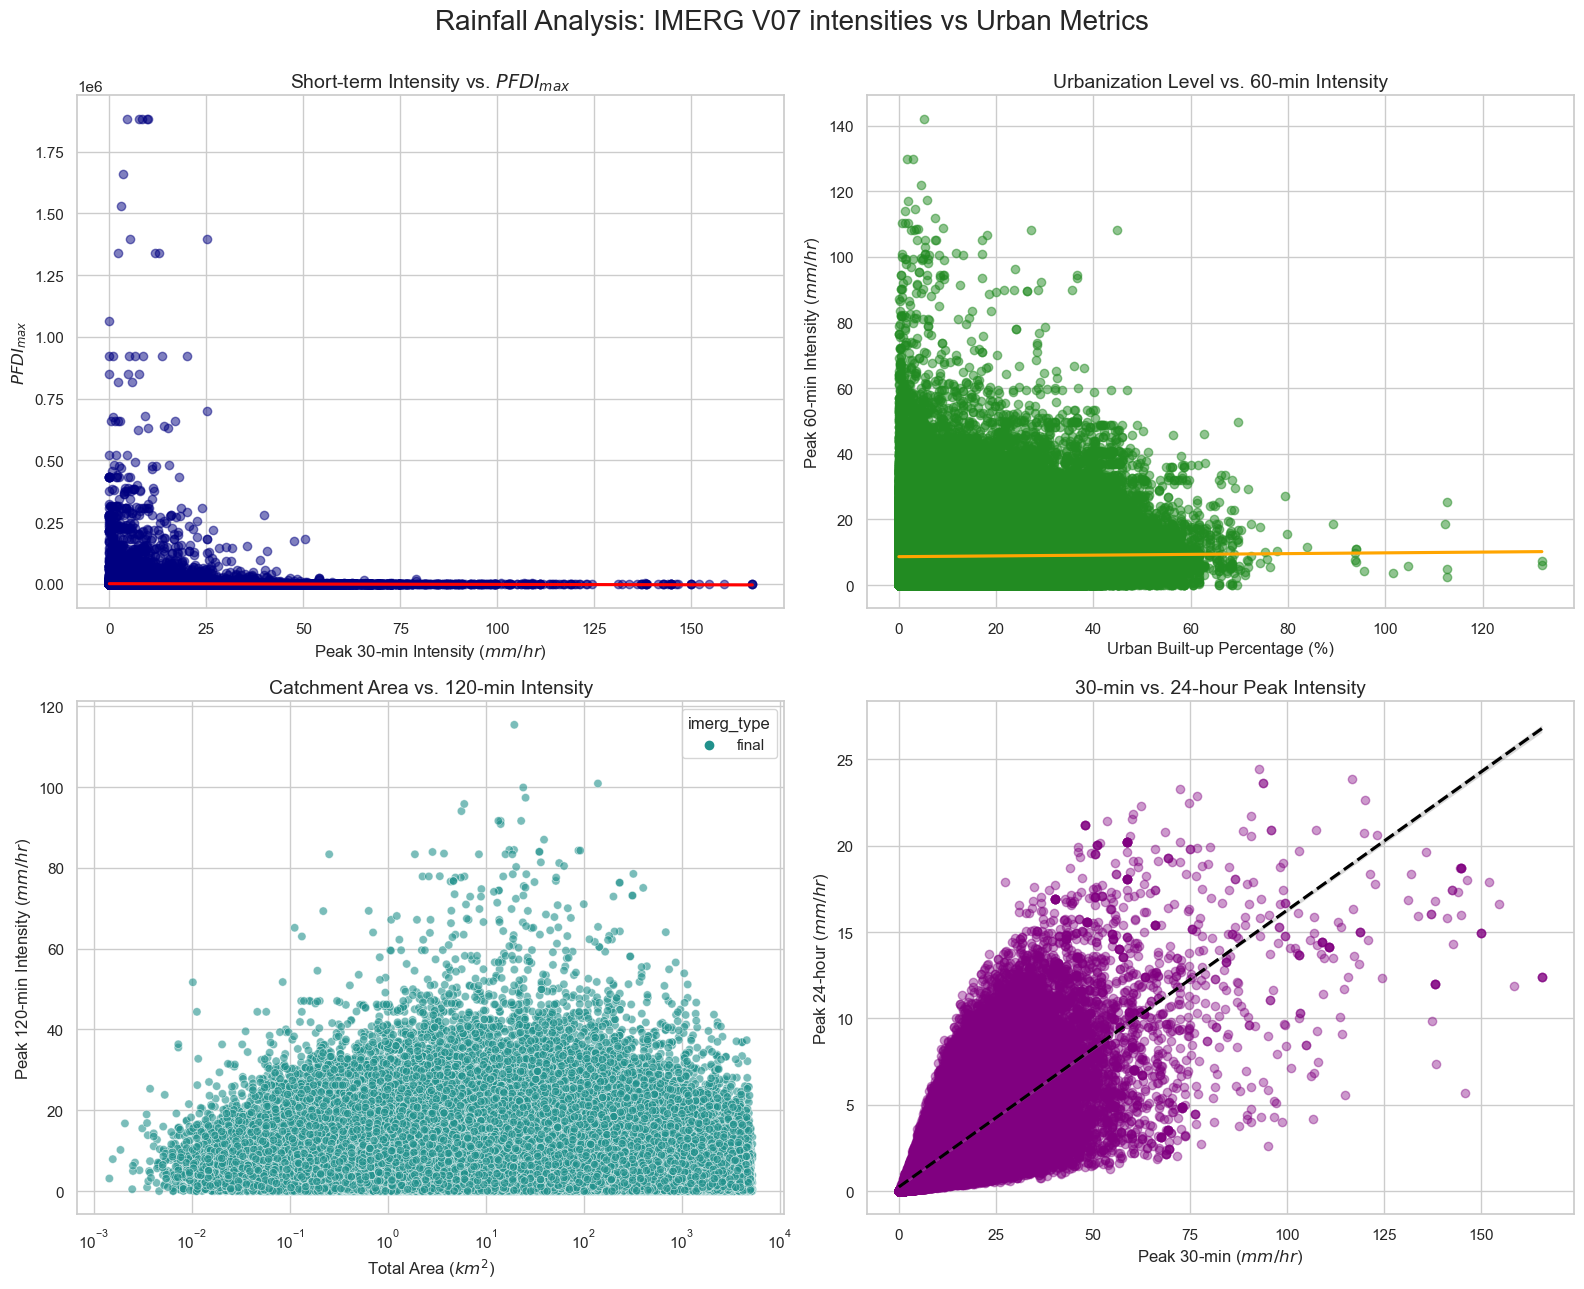

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- 1. SETUP STYLE ---
# Using a clean theme for scientific visualization
sns.set_theme(style="whitegrid")

# Create a figure with 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle(f"Rainfall Analysis: IMERG V07 intensities vs Urban Metrics", fontsize=20, y=0.95)

# --- PLOT 1: Peak Intensity (30m) vs. PFDI Max ---
# Looking for correlation between short-duration intensity and peak damage index
sns.regplot(
    data=final_master_dataset, 
    x='30_max_rainfall_intens', 
    y='PFDI_max', 
    ax=axes[0, 0],
    scatter_kws={'alpha': 0.5, 'color': 'navy'},
    line_kws={'color': 'red'}
)
axes[0, 0].set_title("Short-term Intensity vs. $PFDI_{max}$", fontsize=14)
axes[0, 0].set_xlabel("Peak 30-min Intensity ($mm/hr$)")
axes[0, 0].set_ylabel("$PFDI_{max}$")

# --- PLOT 2: Intensity vs. Urban Percentage ---
# Checking if urbanized areas experience higher satellite-derived intensities
sns.regplot(
    data=final_master_dataset, 
    x='urban_percentage', 
    y='60_max_rainfall_intens', 
    ax=axes[0, 1],
    scatter_kws={'alpha': 0.5, 'color': 'forestgreen'},
    line_kws={'color': 'orange'}
)
axes[0, 1].set_title("Urbanization Level vs. 60-min Intensity", fontsize=14)
axes[0, 1].set_xlabel("Urban Built-up Percentage (%)")
axes[0, 1].set_ylabel("Peak 60-min Intensity ($mm/hr$)")

# --- PLOT 3: Intensity vs. Catchment Area ---
# Understanding the scale effect (Are intensities lower in larger areas?)
sns.scatterplot(
    data=final_master_dataset, 
    x='area_km2', 
    y='120_max_rainfall_intens', 
    hue='imerg_type',
    ax=axes[1, 0],
    alpha=0.6,
    palette='viridis'
)
axes[1, 0].set_title("Catchment Area vs. 120-min Intensity", fontsize=14)
axes[1, 0].set_xlabel("Total Area ($km^{2}$)")
axes[1, 0].set_ylabel("Peak 120-min Intensity ($mm/hr$)")
axes[1, 0].set_xscale('log') # Log scale often helps with area distribution

# --- PLOT 4: Short-duration vs. Long-duration Intensity ---
# Consistency check: 30-min vs 24-hour peak intensities
sns.regplot(
    data=final_master_dataset, 
    x='30_max_rainfall_intens', 
    y='1440_max_rainfall_intens', 
    ax=axes[1, 1],
    scatter_kws={'alpha': 0.4, 'color': 'purple'},
    line_kws={'color': 'black', 'linestyle': '--'}
)
axes[1, 1].set_title("30-min vs. 24-hour Peak Intensity", fontsize=14)
axes[1, 1].set_xlabel("Peak 30-min ($mm/hr$)")
axes[1, 1].set_ylabel("Peak 24-hour ($mm/hr$)")

# Adjust layout to prevent overlap
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()